In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
# plot settings
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'lines.linewidth': 1.2,
    'lines.markersize': 4,
    'legend.fontsize': 9,
    'legend.frameon': True,
    'legend.loc': 'best',
    'axes.grid': False,
    'grid.alpha': 0.3,
    'figure.dpi': 600,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.transparent': True,
    'text.usetex': False,
    'mathtext.default': 'regular'
})
width = 17.5 / 2.54

In [4]:
# load raw dataset
trace_dataset = pd.read_excel('Trace Garnet Dataset.xlsx')
trace_dataset['Type'].value_counts()

Type
Igneous        1250
Peritectic     1227
Metamorphic    1226
Name: count, dtype: int64

In [5]:
trace_dataset.drop(columns=['sample'], inplace=True)

In [6]:
# filter features
threshold = 0.4  # 40%
filtered_trace_dataset = trace_dataset.loc[:, trace_dataset.isnull().mean() <= threshold].copy()

In [7]:
filtered_trace_dataset

,Type,Y,Zr,La,Ce,Pr,Nd,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf
0,Igneous,802.00,17.000,0.020,0.070,0.010,0.680,4.760,0.080,31.800,NaN,103.700,NaN,86.100,NaN,78.700,9.700,NaN
1,Igneous,859.00,11.000,0.020,0.090,0.020,0.840,2.630,0.090,15.600,NaN,89.200,NaN,111.300,NaN,118.100,13.900,NaN
2,Igneous,884.00,6.200,0.240,0.840,0.060,0.640,1.260,0.060,14.800,NaN,99.300,NaN,102.000,NaN,84.400,8.300,NaN
3,Igneous,268.00,4.800,0.010,0.010,0.000,0.270,2.840,0.060,33.200,NaN,65.300,NaN,19.400,NaN,15.900,3.800,NaN
4,Igneous,44.66,13.190,0.051,0.234,0.165,3.570,4.970,2.460,7.910,NaN,8.800,1.790,4.380,NaN,3.950,0.512,0.203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3698,Peritectic,96.68,4.505,0.683,0.683,0.166,1.114,1.548,1.270,8.072,2.455,17.330,2.740,6.326,1.136,5.825,0.635,0.241
3699,Peritectic,158.00,7.158,0.180,0.126,0.035,0.505,2.654,1.728,18.080,4.839,32.300,5.170,11.240,1.427,9.451,0.998,0.076
3700,Peritectic,134.20,3.325,0.694,0.492,0.152,0.883,1.607,1.175,5.158,1.785,16.770,4.072,11.620,1.888,13.230,1.557,0.070
3701,Peritectic,64.41,4.142,0.016,0.030,0.020,0.276,1.341,1.148,3.238,1.089,8.736,1.939,5.017,0.882,5.820,0.681,0.165


In [8]:
filtered_trace_dataset.drop(columns=['La','Ho','Er','Hf','Pr','Tm','Dy','Yb','Gd','Tb'], inplace=True)
feature_names = filtered_trace_dataset.columns[1:]

In [9]:
# fill missing values
filtered_trace_dataset.fillna(0.001, inplace=True)

In [10]:
filtered_trace_dataset['Type'].value_counts()

Type
Igneous        1250
Peritectic     1227
Metamorphic    1226
Name: count, dtype: int64

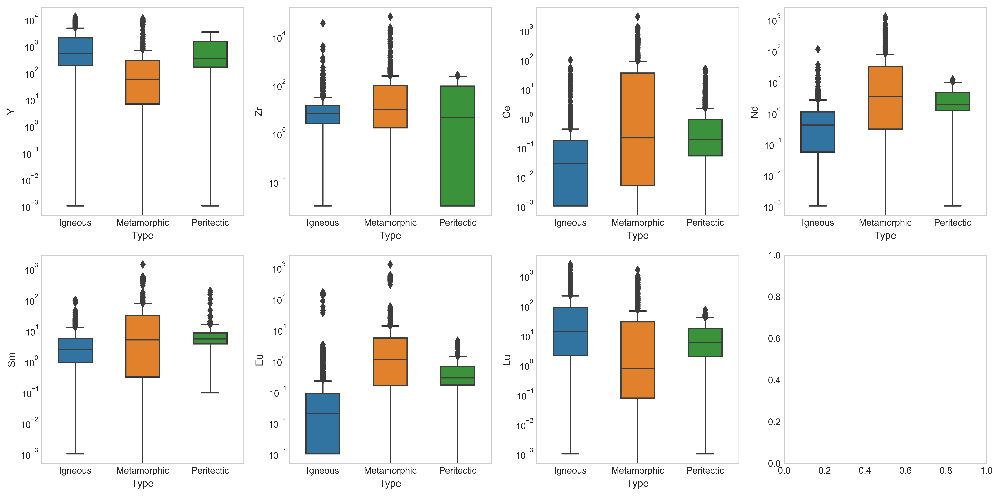

In [11]:
# Trace Element Data
import matplotlib.ticker as ticker
fig, axes = plt.subplots(2, 4, figsize=[width*2, width], dpi=600)
for i in range(7):
    ax = axes[i//4, i-(i//4)*4]
    sns.boxplot(y=filtered_trace_dataset.columns[i+1], x='Type', data=filtered_trace_dataset, ax=ax, width=0.5)
    ax.set_ylabel(feature_names[i])
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.set_yscale('log')
plt.tight_layout()
# plt.savefig('Trace Elements Distribution.svg')
plt.show()

In [12]:
X = filtered_trace_dataset.iloc[:, 1:]
y = filtered_trace_dataset['Type']

In [13]:
# Logarithmic transformation
X_log = np.log1p(X)

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_log, y, test_size=0.2, stratify=y, random_state=10, shuffle=True)

from sklearn.preprocessing import StandardScaler
# Standardization
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [37]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
# RandomizedSearchCV + Cross Validation
parameters = {'max_features':range(1, 9), 'n_estimators':range(25, 525, 25), 'max_depth':range(1, 9), 'min_samples_split':range(5,25,5), 'min_samples_leaf':range(2,12,2)}
grid1 = RandomizedSearchCV(estimator=rf, param_distributions=parameters, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=10), n_iter=200, scoring='f1_macro', random_state=10)
grid1.fit(X_train_scaled, y_train)
print('Results of 200 training rounds for the Random Forest Model: \n',grid1.cv_results_['mean_test_score'])
print('Optimal Random Forest Model Parameters: \n',grid1.best_params_)
print('Optimal Random Forest Model F1_score (Training): ', grid1.best_score_)
print('Optimal Random Forest Model F1_score (Test): ',grid1.best_estimator_.score(X_test_scaled, y_test))

Results of 30 training rounds for the Random Forest Model: 
 [0.9119383  0.85683122 0.91497312 0.85483576 0.82777395 0.8714167
 0.79234856 0.91087825 0.87644574 0.88899311 0.87053686 0.83053567
 0.83370306 0.91185144 0.86899253 0.88919264 0.8941132  0.76162696
 0.92556309 0.90484601 0.91204158 0.66348686 0.82180068 0.85682374
 0.79918336 0.92863278 0.91509001 0.89919553 0.89929395 0.87115875
 0.89186214 0.86778942 0.85598537 0.90009449 0.91261701 0.9126347
 0.83887472 0.7001274  0.84276825 0.64045713 0.84933631 0.66957033
 0.90294101 0.84590164 0.86695289 0.85680555 0.66626031 0.87373659
 0.92285776 0.88615171 0.89185938 0.8551929  0.91759691 0.91278227
 0.87396117 0.91530567 0.79135161 0.92030531 0.68680247 0.75768757
 0.93273966 0.92181201 0.85613844 0.90142517 0.88836876 0.89698802
 0.91140324 0.66722054 0.91135364 0.85136546 0.7606624  0.87511908
 0.82717999 0.85822077 0.87410692 0.90027792 0.89485288 0.89226553
 0.90520329 0.90642352 0.86455049 0.7096292  0.90861704 0.83940128
 0.

In [38]:
# Adaboost Model
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier()
# RandomizedSearchCV + Cross Validation
parameters = {'n_estimators': range(25, 525, 25),'learning_rate':scipy.stats.uniform(0.01, 0.20)}
grid2 = RandomizedSearchCV(estimator=ada, param_distributions=parameters, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=10), n_iter=200, scoring='f1_macro', random_state=10)
grid2.fit(X_train_scaled, y_train)
print('Results of 200 training rounds for the Adaboost Model: \n',grid2.cv_results_['mean_test_score'])
print('Optimal Adaboost Model Parameters: \n',grid2.best_params_)
print('Optimal Adaboost Model F1_score (Training): ', grid2.best_score_)
print('Optimal Adaboost Model F1_score (Test): ',grid2.best_estimator_.score(X_test_scaled, y_test))

Results of 30 training rounds for the Adaboost Model: 
 [0.85976764 0.86610993 0.86909917 0.8425199  0.85738821 0.84185085
 0.85586888 0.84099253 0.82430725 0.86371288 0.86577359 0.85909437
 0.85495113 0.85486787 0.84163646 0.84545531 0.86404632 0.86707237
 0.85462589 0.86037789 0.8707758  0.84399212 0.82803588 0.84310379
 0.8694665  0.84461798 0.86247638 0.84558398 0.84413439 0.86746732
 0.82006487 0.85176065 0.85454178 0.85870608 0.86374566 0.85612185
 0.84778554 0.85546244 0.84955813 0.86444232 0.86011223 0.86147075
 0.85711846 0.84658009 0.85685566 0.85182751 0.86872892 0.84474698
 0.85614918 0.76635679 0.84894499 0.8617947  0.85043344 0.86448187
 0.8640743  0.84832828 0.84689888 0.85223097 0.86703485 0.85533408
 0.85488535 0.86338412 0.86076458 0.85654146 0.85434048 0.84262029
 0.84573073 0.82327777 0.85648975 0.86234076 0.86814215 0.85594017
 0.86003595 0.86175919 0.83755709 0.86644057 0.84972306 0.81665162
 0.85562936 0.86809501 0.85214957 0.85492306 0.8693973  0.85393994
 0.856

In [39]:
# XGBoost Model
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

from xgboost import XGBClassifier
xgb = XGBClassifier()
# RandomizedSearchCV + Cross Validation
parameters = {'n_estimators':range(25, 525, 25), 'max_depth':range(1, 9), 'learning_rate':scipy.stats.uniform(0.01, 0.20), 'reg_alpha': scipy.stats.uniform(0, 1), 'reg_lambda': scipy.stats.uniform(0.5, 2.5)}
grid3 = RandomizedSearchCV(estimator=xgb, param_distributions=parameters, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=10), n_iter=200, scoring='f1_macro', random_state=10)
grid3.fit(X_train_scaled, y_train_encoded)
print('Results of 200 training rounds for the XGBoost Model: \n',grid3.cv_results_['mean_test_score'])
print('Optimal XGBoost Model Parameters: \n',grid3.best_params_)
print('Optimal XGBoost Model F1_score (Training): ', grid3.best_score_)
print('Optimal XGBoost Model F1_score (Test): ',grid3.best_estimator_.score(X_test_scaled, y_test_encoded))

Results of 30 training rounds for the XGBoost Model: 
 [0.94675367 0.88717475 0.9447629  0.87767666 0.94271155 0.94877056
 0.92823185 0.94739404 0.85840251 0.9376817  0.94639344 0.89262769
 0.94641988 0.94675843 0.91163874 0.85004405 0.87349648 0.93195353
 0.87070191 0.9491173  0.94437515 0.92963492 0.94710803 0.9487523
 0.87001082 0.94708594 0.9477655  0.94711541 0.9484402  0.85691385
 0.94944554 0.94874416 0.94640409 0.93267104 0.88174585 0.86204287
 0.94372315 0.94741138 0.94539019 0.94744946 0.94776327 0.94808594
 0.9460859  0.87210597 0.94068365 0.9320441  0.93915042 0.92491224
 0.94777132 0.94674941 0.94976418 0.86311373 0.94743102 0.87106076
 0.8867767  0.86558131 0.93158421 0.94375485 0.84250221 0.94336762
 0.9470623  0.94947084 0.94945053 0.94876085 0.94308813 0.92257024
 0.94740911 0.94439844 0.94110235 0.9494433  0.94439012 0.91026997
 0.94138475 0.94742647 0.94202912 0.948412   0.93532023 0.95011997
 0.89620717 0.93571725 0.94506083 0.94675008 0.9491246  0.94773827
 0.93228

In [40]:
# SVM Model
from sklearn.svm import SVC
svc = SVC()
# RandomizedSearchCV + Cross Validation
parameters = {'C':np.arange(0.001, 10.001, 0.05), 'kernel':['linear', 'poly', 'rbf', 'sigmoid']}
grid4 = RandomizedSearchCV(estimator=svc, param_distributions=parameters, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=10), n_iter=200, scoring='f1_macro', random_state=10)
grid4.fit(X_train_scaled, y_train)
print('Results of 200 training rounds for the SVM Model: \n',grid4.cv_results_['mean_test_score'])
print('Optimal SVM Model Parameters: \n',grid4.best_params_)
print('Optimal SVM Model F1_score (Training): ', grid4.best_score_)
print('Optimal SVM Model F1_score (Test): ',grid4.best_estimator_.score(X_test_scaled, y_test))

Results of 30 training rounds for the SVM Model: 
 [0.6219825  0.90776352 0.92464562 0.81084141 0.49881703 0.90507148
 0.89459121 0.51201193 0.50872459 0.49726474 0.81255872 0.81122805
 0.81189093 0.50339999 0.5166952  0.89152119 0.81113703 0.81113703
 0.49793016 0.90071432 0.89247678 0.49797121 0.58284272 0.88223813
 0.896658   0.81122805 0.81084141 0.81113703 0.88191553 0.49919194
 0.81046953 0.90037186 0.89056116 0.91765573 0.50341948 0.81080376
 0.81119097 0.87398875 0.8221272  0.89630934 0.8909008  0.49797121
 0.81044329 0.89577116 0.8979994  0.81184649 0.81116377 0.89056116
 0.50023904 0.87301115 0.89281067 0.81046953 0.89510388 0.49938749
 0.81084141 0.81113703 0.81116377 0.5034437  0.81086826 0.85955373
 0.87340929 0.88450527 0.86485581 0.50342669 0.81080376 0.81083161
 0.84856197 0.81155098 0.4989716  0.51196421 0.81118316 0.81077656
 0.89413569 0.81046953 0.50092528 0.88017989 0.50306952 0.81113703
 0.4989716  0.52224602 0.81189093 0.81122805 0.87875735 0.81110528
 0.81080376

In [41]:
models = [grid1.best_estimator_, grid2.best_estimator_, grid3.best_estimator_, grid4.best_estimator_]
names = ['Random Forest', 'AdaBoost', 'XGBoost', 'SVM']

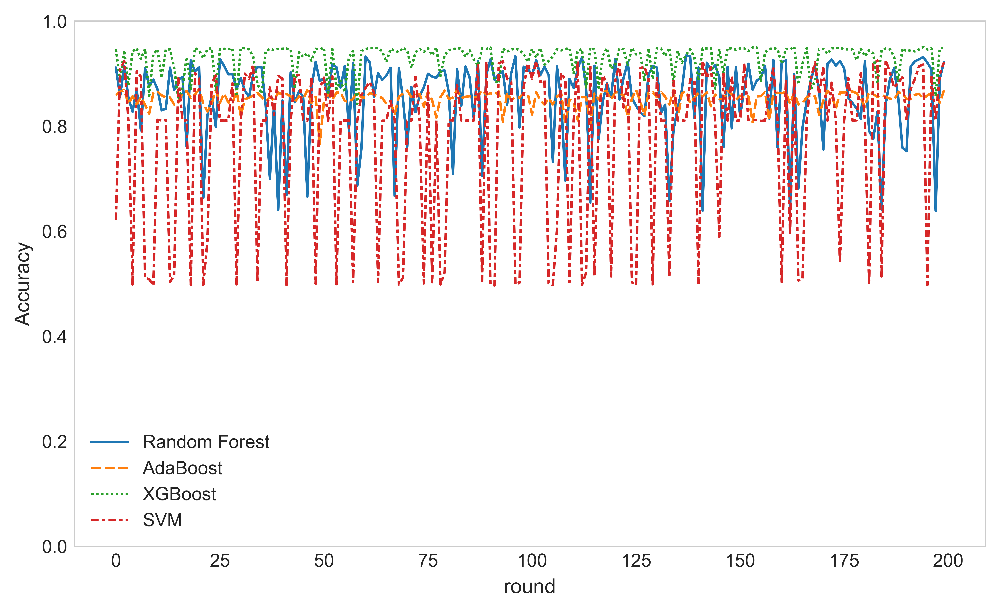

In [50]:
# Hyperparameter Tuning Results
Accuracy_df = pd.DataFrame({'Random Forest': grid1.cv_results_['mean_test_score'], 'AdaBoost': grid2.cv_results_['mean_test_score'], 
                            'XGBoost': grid3.cv_results_['mean_test_score'], 'SVM': grid4.cv_results_['mean_test_score']})

plt.figure(figsize=[width, width*0.618], dpi=900)

sns.lineplot(data=Accuracy_df)
plt.xlabel('round')
plt.ylabel('F1_score')
plt.ylim([0,1])
plt.legend(frameon=False)
plt.tight_layout()
# plt.savefig('Minor_accuracy_line_results.svg', bbox_inches='tight')
plt.show()

In [44]:
for i in range(4):
    print('%s Min F1_score: %f'%(names[i], Accuracy_df[names[i]].min()))
    print('%s Max F1_score: %f'%(names[i], Accuracy_df[names[i]].max()))
    print('%s Mean F1_score: %f\n'%(names[i], Accuracy_df[names[i]].mean()))  

Random Forest Min: 0.639176
Random Forest Max: 0.934774
Random Forest Mean: 0.857990

AdaBoost Min: 0.766357
AdaBoost Max: 0.870776
AdaBoost Mean: 0.853226

XGBoost Min: 0.842502
XGBoost Max: 0.952086
XGBoost Mean: 0.930644

SVM Min: 0.497058
SVM Max: 0.925988
SVM Mean: 0.775083



In [24]:
# Confusion Matrix of Prediction
from sklearn.metrics import precision_score, f1_score, recall_score, confusion_matrix
def Confusion_Matrix_Plot(model, X, y, ax):
    try:
        sns.heatmap(confusion_matrix(y, model.predict(X)), annot=True, linewidths=0.6, cmap='Blues', cbar=False, fmt='d', square=True, annot_kws={'size':6}, ax=ax)
    except:
        sns.heatmap(confusion_matrix(y, le.inverse_transform(model.predict(X))), annot=True, linewidths=0.6, cmap='Blues', cbar=False, fmt='d', square=True, annot_kws={'size':6}, ax=ax)
    ax.set_xticks([i+0.5 for i in range(3)], label_names, size=8)
    ax.set_yticks([i+0.5 for i in range(3)], label_names, size=8, rotation=0)

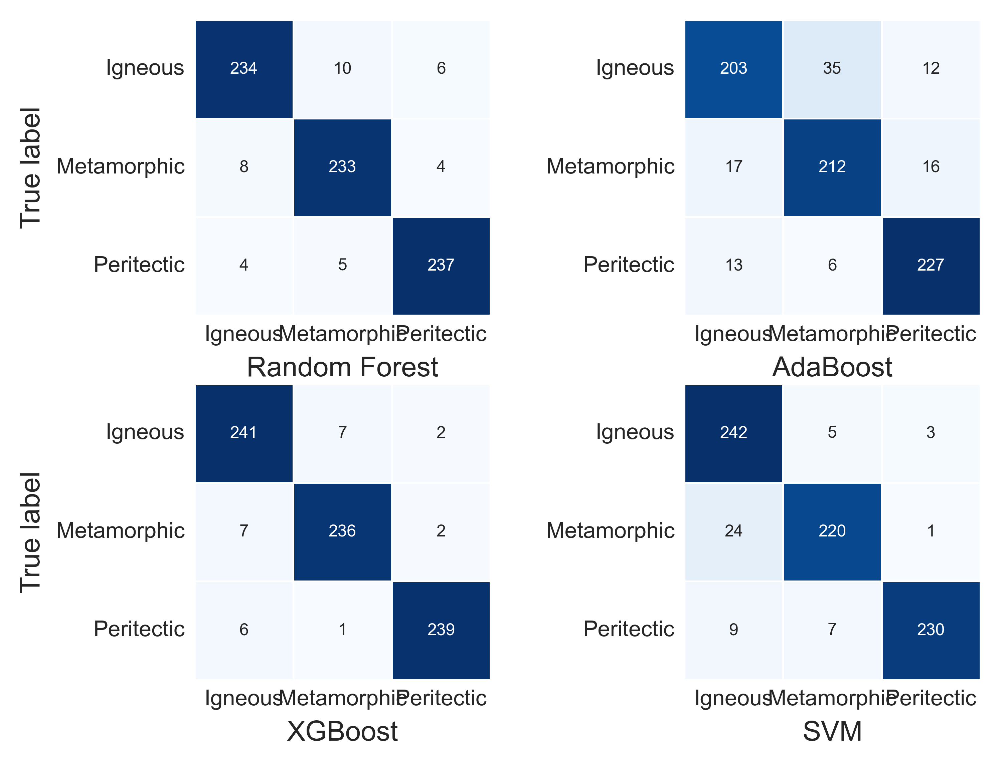

In [45]:
label_names = grid1.classes_
fig, axes = plt.subplots(2, 2, dpi=600)
for i in range(4):
    ax = axes[i//2, i-(i//2)*2]
    Confusion_Matrix_Plot(models[i], X_test_scaled, y_test, ax)
    ax.set_xlabel(names[i])
axes[0,0].set_ylabel('True label')
axes[1,0].set_ylabel('True label')
plt.tight_layout(h_pad=0.1)
# plt.savefig('Trace_Feature_importance_ConfusionMatrix.svg', bbox_inches='tight')
plt.show()

In [26]:
# PCA Analysis
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
PCA_df = pd.DataFrame(pca.fit_transform(scaler.fit_transform(X_log)),columns=['PCA1','PCA2'])
PCA_df['Type'] = y

PCA_output = ['', '']
for i in range(2):
    for j in range(feature_names.shape[0]):
        if pca.components_[i][j] > 0:
            PCA_output[i] += '+ '+'{:.2f}'.format(pca.components_[i][j])+'*'+feature_names[j]+' '
        else:
            PCA_output[i] += ' '+'{:.2f}'.format(pca.components_[i][j])+'*'+feature_names[j]+' '
    PCA_output[i] = PCA_output[i][1:]

print('PCA1 = ', PCA_output[0])
print('PCA2 = ', PCA_output[1])

PCA1 =   0.15*Y + 0.28*Zr + 0.41*Ce + 0.46*Nd + 0.47*Sm + 0.46*Eu + 0.29*Lu 
PCA2 =  -0.68*Y + 0.01*Zr + 0.35*Ce + 0.25*Nd  -0.13*Sm + 0.15*Eu  -0.56*Lu 


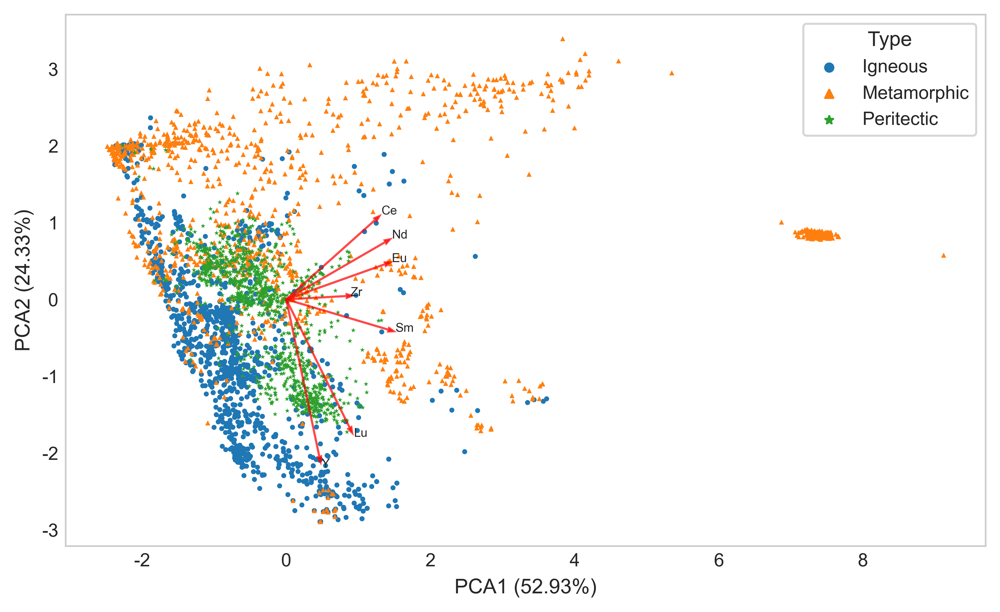

In [27]:
plt.figure(figsize=(width, width*0.618))
    
# plot points
marker_dict = {'Igneous': 'o', 'Peritectic': '*', 'Metamorphic': '^'}
# plt.figure(figsize=(width, width*0.618), dpi=900)
sns.scatterplot(x=PCA_df['PCA1'], y=PCA_df['PCA2'], hue=PCA_df['Type'], style=PCA_df['Type'], markers=marker_dict, s=6, edgecolor='none')
    
# feature vectors
for i, (comp1, comp2) in enumerate(zip(pca.components_[0], pca.components_[1])):
    plt.arrow(0, 0, comp1 * 3, comp2 * 3, color='r', alpha=0.7, head_width=0.05)
    plt.text(comp1 * 3.2, comp2 * 3.2, feature_names[i], size=6)
   
plt.xlabel('PCA1 (%.2f%%)' % (pca.explained_variance_ratio_[0] * 100))
plt.ylabel('PCA2 (%.2f%%)' % (pca.explained_variance_ratio_[1] * 100))
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
plt.tight_layout()
# plt.savefig('Trace_PCA.svg', bbox_inches='tight')
plt.show()

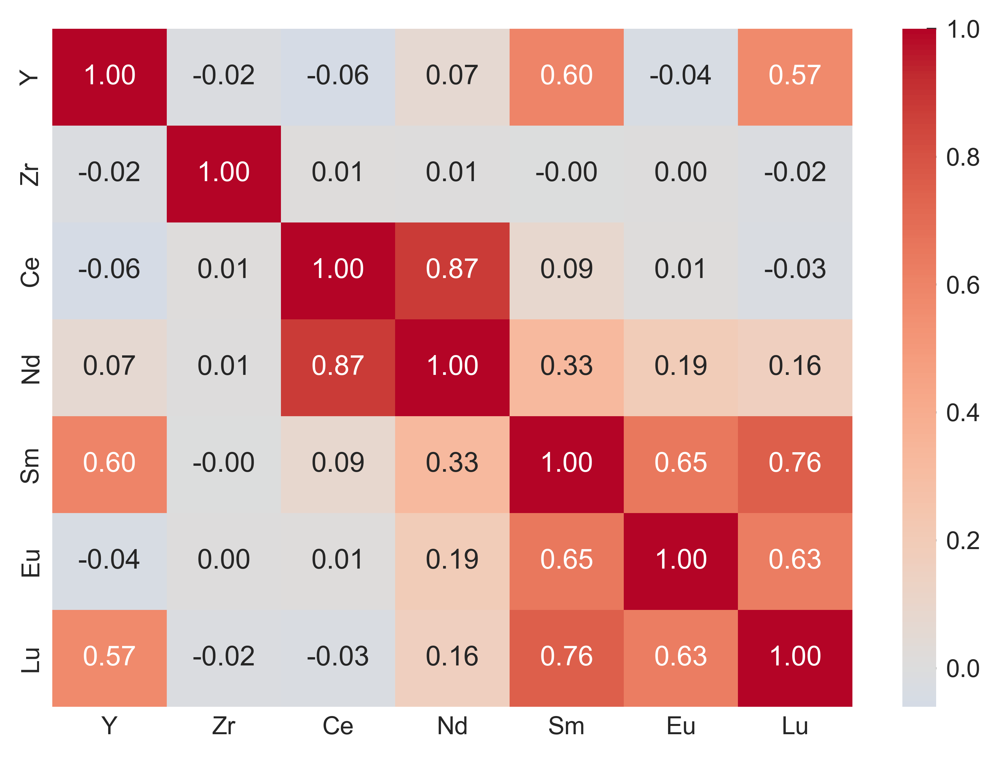

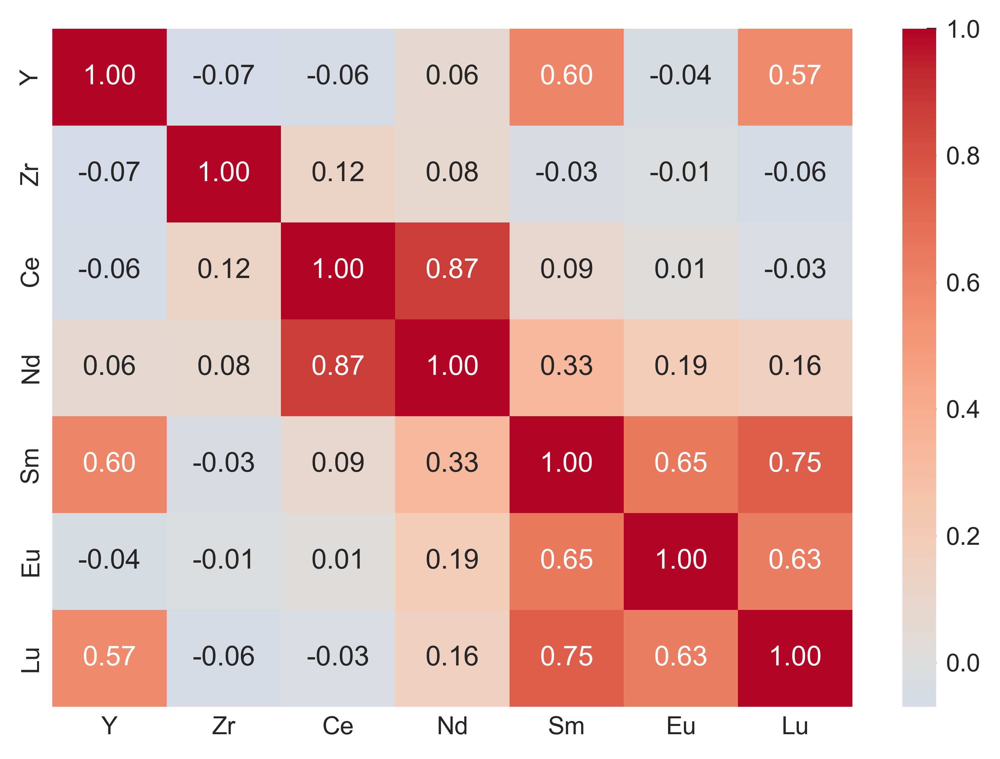

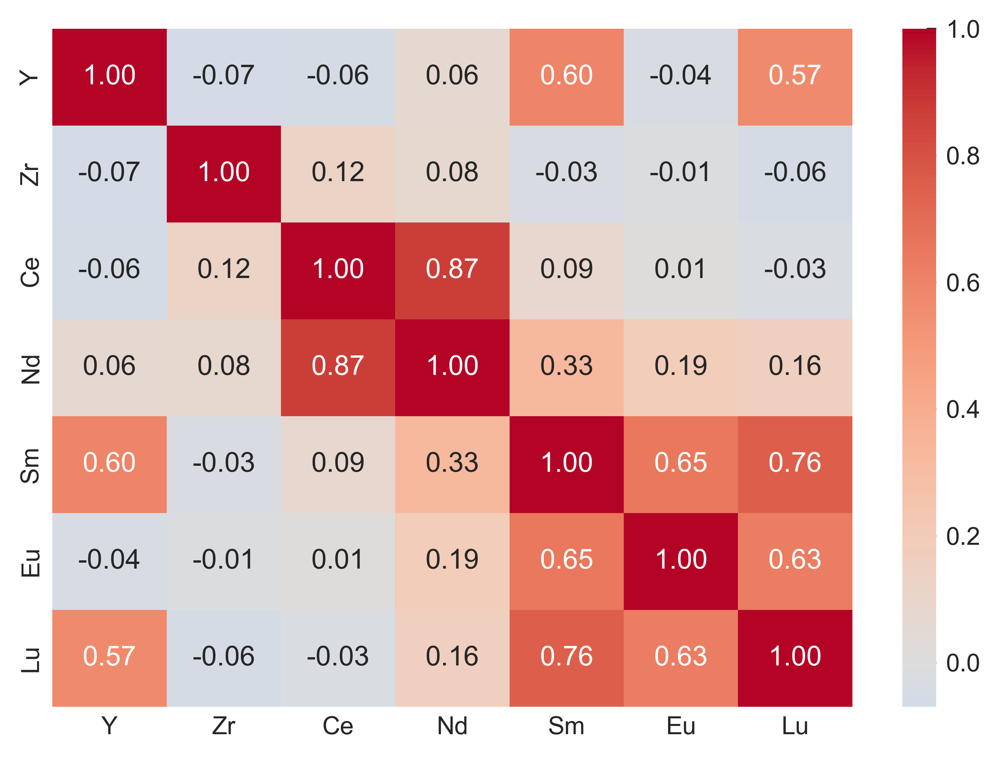

In [28]:
# Correlation Matrix
for i in range(3):
    df = filtered_trace_dataset[filtered_trace_dataset['Type']==['Igneous','Metamorphic','Peritectic'][i]].reset_index()
    index = df.index
    data = filtered_trace_dataset.iloc[:, 1:]
    corr_matrix = np.corrcoef(scaler.fit_transform(data)[index].T)

    # plt.figure(figsize=(width, width*0.8), dpi=900)
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',center=0,xticklabels=feature_names,yticklabels=feature_names)
    plt.tight_layout()
    # plt.savefig('Trace PearsonCorrelation %s.svg'%label_names[i])
    plt.show()

In [48]:
# SHAP Analysis
import shap
explainer = shap.TreeExplainer(grid3.best_estimator_)
shap_values = explainer.shap_values(X_train_scaled)
print(shap_values.shape)
print(explainer.expected_value)

(2962, 7, 3)
[0.14434302, 0.13893165, -0.26245475]


C:\Windows\Temp\ipykernel_27540\406047152.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


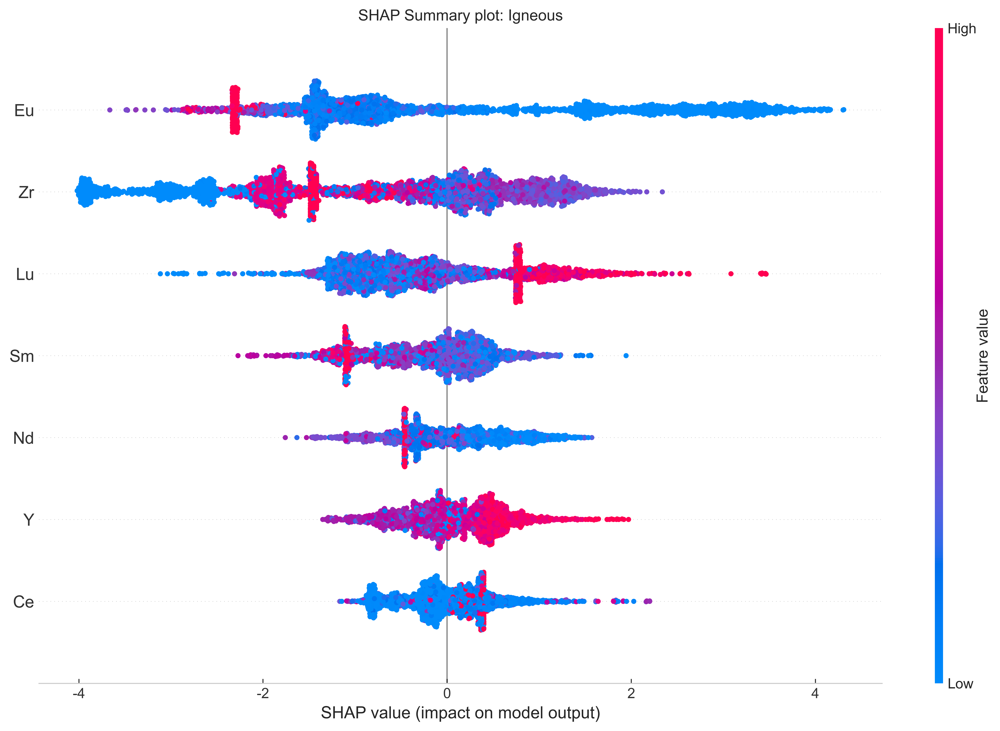

C:\Windows\Temp\ipykernel_27540\406047152.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


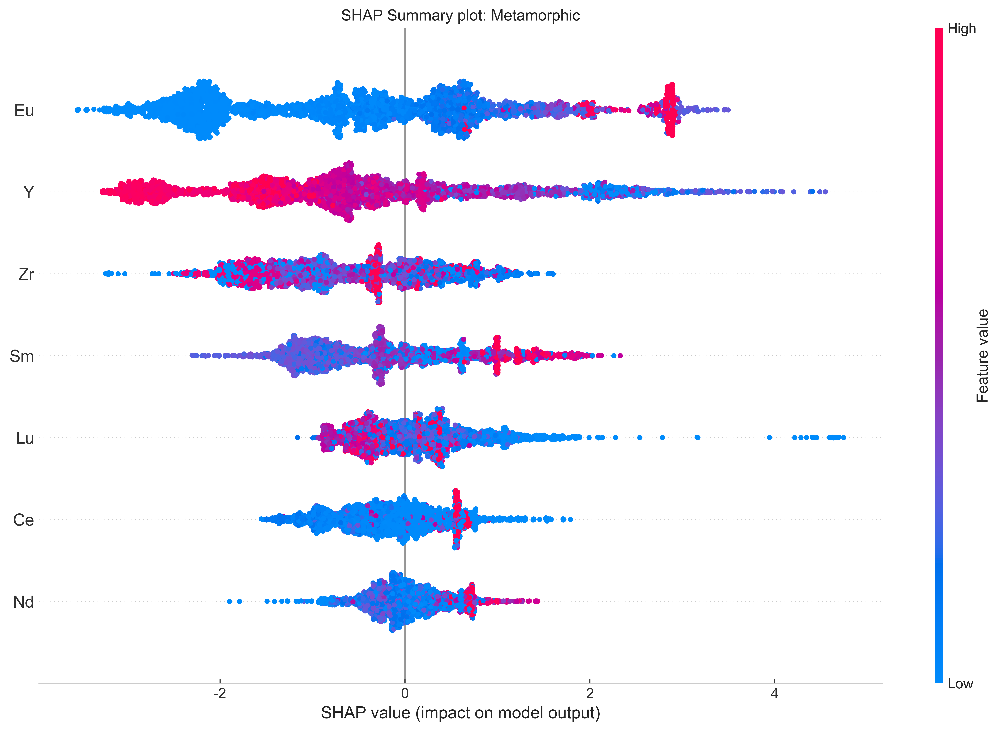

C:\Windows\Temp\ipykernel_27540\406047152.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


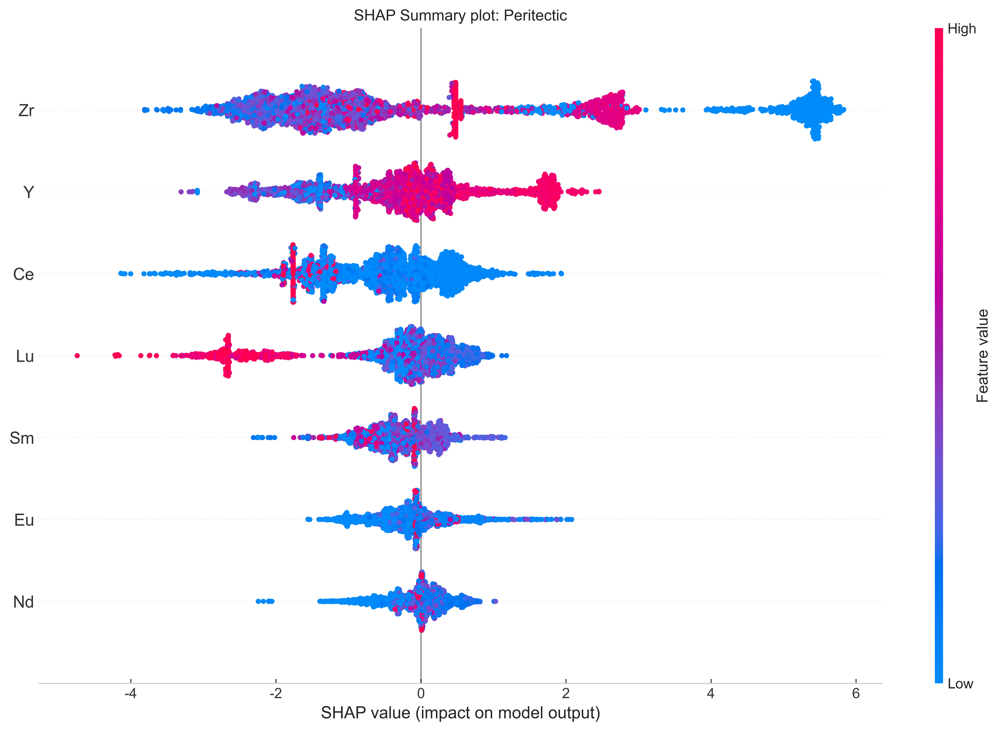

In [49]:
for i in range(3):
    # plt.figure(figsize=(width, width*0.618), dpi=900)
    plt.title('SHAP Summary plot: %s'%label_names[i]) # SHAP Summary Plot 
    shap.summary_plot(shap_values[:,:,i],X_train,feature_names=feature_names,plot_type='dot',plot_size=(12, 8), show=False)
    plt.tight_layout()
    # plt.savefig('SHAP Trace %s.svg'%label_names[i])
    plt.show()

In [47]:
# save models
import pickle
with open('Scaler_trace_model.pkl', 'wb') as f:
    pickle.dump(scaler, f)
    
with open('XGBoost_trace_model.pkl', 'wb') as f:
    pickle.dump(grid3.best_estimator_, f)